# Q12. Can better features and head fitting improve Evo2 LoRA?

A one-hour exploratory experiment on the prepared H100. Preserve variant-effect magnitude, fit the classifier before LoRA, and compare continued LoRA training against a matched frozen-backbone classifier. Prerequisites are the completed [Q11 model](Q11-evo2-lora.ipynb), [Q11 diagnostic sample](Q11-lora-diagnostics.ipynb), and their verified inputs/runtime. [Implementation](src/q12.py) · [GPU workflow](src/q12_backend.py) · [Setup](../README.md#setup).

In [1]:
from src import q12

## Frozen inputs and authorized exploratory scope

Retain Q1’s complete July missense partitions and all original leakage checks. Use exactly the same **24,576 of 46,888 training variants** seen by Q11. Monitoring uses the existing uniform seed-42 **2,048 of 17,927 validation variants**, across 823 Q1 components. Freeze membership and source hashes before fitting. These subsets are explicitly authorized for exploration; no samples change the full benchmark. Only paired DNA sequences enter feature construction.

In [2]:
protocol = q12.prepare()

Frozen 24,576/46,888 training rows and 2,048/17,927 validation rows.


## Features, classifier fitting and matched continuation

Keep the original pinned 7B backbone, 512-base canonical paired strand and final-block mean pooling. Cache frozen features once. Compare three heads: (1) normalized reference plus allele difference; (2) those features plus log difference RMS and log relative difference RMS; (3) normalized difference plus the two log magnitudes, omitting reference. RMS floor **1e-12**; fit feature means/stds only on training rows (std floor **1e-6**) and freeze them during adaptation.

Each FP32 linear head gets **20 epochs**, batch **512**, AdamW **1e-3**, weight decay **0.01**, balanced training-subset class weights, clipping **1.0**, seed **42**. Select by sampled AUROC, then average precision, then fewer features. No validation data fit preprocessing or gradients.

Start rank-8/alpha-16 LoRA with zero B matrices in the same two block-30 projections as Q11. Clone the selected head into a frozen-backbone control. Both branches receive identical batches and update counts; LoRA uses live features and the control uses cached features. Batch **32**, at most **768 updates**, adapter learning rate **1e-4**, head learning rate **3e-5**, BF16 adapters/backbone with FP32 optimizer masters/head and original weights frozen.

## Monitoring, stopping and integrity

Evaluate initially, every **256 updates**, and at stopping. Stop after **two checks** without at least **0.002 AUROC** progress or when the one-hour budget needs its final validation/report reserve. Calibrate inference speed using training rows; reserve one sample evaluation and reload check with a **30% margin**, plus **three minutes** for reporting. Save matched optimizer/RNG/cursor state every 32 updates; resuming retains the original deadline.

Keep the best LoRA checkpoint together with its control from the same update count. Also retain the best frozen control across monitored steps. Select LoRA only if it exceeds the best control AUROC by **at least 0.005** without reducing AP. Otherwise select the control. The paired effect uses the control from the same update count as the best LoRA checkpoint.

Training-only probes check repeatability, strand/batch equivalence, zero-adapter equivalence, finite gradients and actual adapter/head updates, then restore their changes. Verify unchanged original backbone tensors. Erase learned tensors and reload the selected checkpoint to reproduce 64 scores.

In [3]:
result = q12.run_experiment()

explore: notebooks/results/q12/explore.log


## Sampled development results

AUROC and average precision use 1,000 whole-component bootstrap resamples, seed 42. These intervals do not correct feature, checkpoint or stopping selection bias. The figure shows matched continuation progress and precision–recall curves. A negative result is a valid outcome.

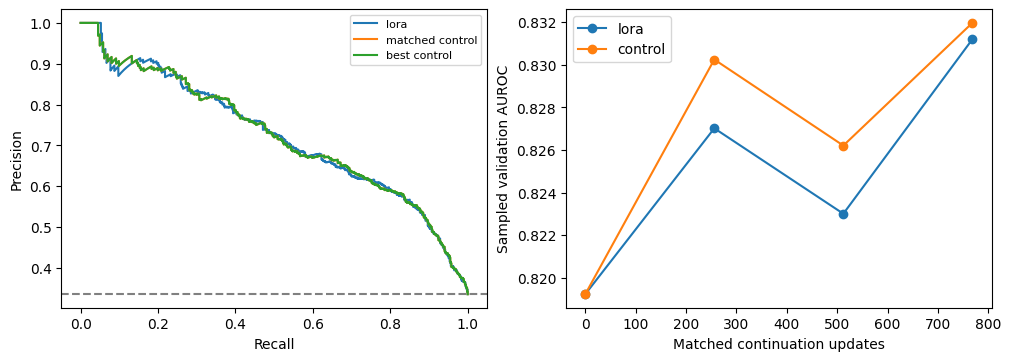

In [4]:
q12.show_results()

## Conclusion

Full validation is separate: `.venv/bin/python -m notebooks.src.refresh_q12 --full-validation`. That entrypoint executes another notebook on all 17,927 variants before exporting a benchmark row. This exploratory notebook contributes a README research entry, not sampled benchmark scores.

In [5]:
q12.show_conclusion()

**Conclusion.** Selected **frozen_control**, using **with_magnitude** features. AUROC **0.832**, average precision **0.725**, on **2,048** validation variants. Best LoRA minus its control at the same update count: AUROC **-0.001** (95% component interval **[-0.003, +0.002]**). The selection rule retained the frozen-backbone control. Continuation stopped after **768** updates: **max_steps**. These sampled development results do not replace full-cohort benchmark measurements. User-authorized exploratory training subset and fixed validation sample. Validation chooses features, checkpoints and early stopping; bootstrap intervals do not correct selection bias. The matched control uses the same initialization, examples, batches and continuation update count as LoRA. The best control can come from another monitored step and is reported separately. No untouched test or clinical validation; pretraining/homology/shared-patient overlap remain unresolved.